# Tabla de Contenido — Flujo de Modelado de Visión por Computadora

## 1. Configuración del Entorno y Parámetros Globales
* Configuración de dependencias, hiperparámetros y validación del entorno computacional (CPU/GPU).

## 2. Limpieza, Curación y Persistencia del Dataset Original
* Filtrado de imágenes inválidas, eliminación de duplicados perceptuales y almacenamiento del dataset procesado en Google Drive.

## 3. Carga y Restauración del Dataset Preprocesado
* Sincronización con Google Drive y restauración estructurada del conjunto de datos curado.

## 4. Ingeniería de Datos y Vectorización de Muestras
* Codificación de etiquetas, redimensión espacial, aplanamiento matricial, partición estratificada y normalización mediante StandardScaler.

## 5. Entrenamiento, Evaluación y Estudio de Ablación
* **5.1. Implementación del Banco de Clasificadores**
* **5.2. Estudio de Ablación y Optimización Paramétrica**
    * *Ejecución de configuraciones para análisis de subajuste, equilibrio y sobreajuste.*

## 6. Análisis Gráfico y Comparación Inter-Modelo
* Generación de gráficas comparativas y matrices de confusión absolutas y normalizadas para el diagnóstico de errores.

# 1. Configuración del Entorno y Parámetros Globales
En esta sección se preparan las librerías necesarias y se definen los valores básicos para procesar las imágenes, como el tamaño de los lotes en memoria y los filtros para detectar imágenes duplicadas. También se revisa si hay una GPU disponible para que el código corra más rápido.

In [ ]:
!pip install datasets pandas numpy matplotlib seaborn plotly wordcloud -q imagehash

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 8.0 MB/s eta 0:00:00


In [ ]:
!pip install datasets Pillow imagehash -q

In [ ]:
import warnings
import time
import os
import io
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import imagehash
from tqdm.notebook import tqdm
import torch
from datasets import load_dataset, load_from_disk
from google.colab import drive
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

warnings.filterwarnings('ignore')

BATCH_SIZE = 64
MIN_SIZE = 32
DIST_MAX = 2
HASH_SIZE = 16

device = 0 if torch.cuda.is_available() else -1
print(f"✅ Dispositivo de cómputo configurado: {'GPU' if device == 0 else 'CPU'}")

✅ Dispositivo de cómputo configurado: GPU


# 2. Limpieza y Guardado del Dataset
Aquí se descarga el dataset de imágenes en su estado original y se pasa por un proceso de limpieza. Se eliminan las imágenes que son demasiado pequeñas, las que son de un solo color sólido (sin información) y las que están repetidas usando un sistema de huella digital (Hash). Al final, el dataset limpio se guarda en tu Google Drive para no tener que repetir este proceso después.

In [ ]:
print('Cargando dataset desde el repositorio central...')
dataset = load_dataset('imageomics/rare-species', split='train', trust_remote_code=True)
print(f"✅ {len(dataset):,} imágenes cargadas en crudo.\n")

def limpiar_dataset_v2(dataset):
    n_total, conservadas, hashes_vistos, cnt_invalidas, cnt_duplicadas, cnt_errores = len(dataset), [], [], 0, 0, 0
    lotes = [list(range(i, min(i + BATCH_SIZE, n_total))) for i in range(0, n_total, BATCH_SIZE)]
    print(f"🔍 Procesando {n_total:,} imágenes distribuidas en {len(lotes)} lotes...")
    t0 = time.time()

    for n_lote, lote_idx in enumerate(tqdm(lotes, desc="Limpiando Dataset"), 1):
        for i in lote_idx:
            try:
                item = dataset[i]
                img = item['file_name']
                if isinstance(img, dict) and 'bytes' in img:
                    img = Image.open(io.BytesIO(img['bytes']))
                img = img.convert('RGB')

                w, h = img.size
                if w < MIN_SIZE or h < MIN_SIZE:
                    cnt_invalidas += 1; del img; continue

                arr = np.array(img); es_solida = int(arr.max()) == int(arr.min()); del arr
                if es_solida:
                    cnt_invalidas += 1; del img; continue

                img_small = img.resize((128, 128))
                h_nuevo = imagehash.phash(img_small, hash_size=HASH_SIZE)
                del img, img_small

                if any((h_nuevo - h_prev) <= DIST_MAX for h_prev in hashes_vistos):
                    cnt_duplicadas += 1; continue

                hashes_vistos.append(h_nuevo)
                conservadas.append(i)
            except Exception:
                cnt_errores += 1; continue
        if n_lote % 10 == 0:
            gc.collect()

    elapsed = time.time() - t0
    print(f"\n{'='*45}\n  RESULTADO FINAL DE LA CURACIÓN\n{'='*45}")
    print(f"  Total analizadas : {n_total:,}\n  ✅ Conservadas   : {len(conservadas):,}\n  🗑️  Duplicadas    : {cnt_duplicadas:,}\n  ⚠️  Inválidas     : {cnt_invalidas:,}\n  ❌ Errores       : {cnt_errores:,}\n  ⏱️  Tiempo total  : {elapsed:.0f}s\n{'='*45}")
    return conservadas

indices_limpios = limpiar_dataset_v2(dataset)
dataset_limpio = dataset.select(indices_limpios)
gc.collect()

print("\nConectando con Google Drive para almacenamiento...")
drive.mount('/content/drive')
ruta_drive = "/content/drive/MyDrive/dataset_limpio"
os.makedirs(ruta_drive, exist_ok=True)
dataset_limpio.save_to_disk(ruta_drive)
print(f"✅ Dataset serializado con éxito en: {ruta_drive}")

`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imageomics/rare-species' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'imageomics/rare-species' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


Cargando dataset desde el repositorio central...


data/train-00005-of-00009.parquet:   0%|          | 0.00/468M [00:00<?, ?B/s]

KeyboardInterrupt: 

# 3. Carga del Dataset desde Google Drive
Esta sección sirve para conectar Google Drive y volver a cargar el dataset que ya limpiamos y guardamos anteriormente. Esto te permite continuar trabajando directamente con las imágenes limpias sin necesidad de volver a correr todo el proceso de filtrado y desduplicación.

In [ ]:
drive.mount('/content/drive')
dataset_limpio = load_from_disk("/content/drive/MyDrive/dataset_limpio")
print(f"✅ Dataset restaurado correctamente: {len(dataset_limpio):,} registros cargados.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Dataset restaurado correctamente: 11,825 registros cargados.


# 4. Preparación de los Datos y Vectorización
En esta sección transformamos las imágenes en números para que los modelos puedan procesar la información. El procedimiento se realiza en dos pasos sencillos:

## 4.1. Convertir Imágenes a Números
Cambiamos los nombres de las clases por etiquetas numéricas y ajustamos todas las imágenes a un tamaño uniforme de 32x32 píxeles, aplanando sus matrices tridimensionales en una sola fila de números (vectorización).

## 4.2. Separar y Normalizar los Datos
Separamos los datos vectorizados en un grupo para entrenar (80%) y otro para hacer pruebas (20%), asegurando que la proporción original de cada clase se mantenga igual en ambos conjuntos. Finalmente, aplicamos un escalado estándar para normalizar los valores numéricos.

In [ ]:
def dataset_to_numpy(dataset):
    X, y = [], []
    clases = list(set(item['class'] for item in dataset))
    label_map = {clase: i for i, clase in enumerate(clases)}
    print("🔍 Clasificación Taxonómica - Número de clases:", len(label_map))

    for item in dataset:
        try:
            img = item['file_name'].convert('RGB').resize((32, 32))
            arr = np.array(img)
            if arr.shape != (32, 32, 3):
                continue
            X.append(arr.flatten())
            y.append(label_map[item['class']])
        except:
            continue
    return np.array(X, dtype=np.float32), np.array(y), label_map

X, y, label_map = dataset_to_numpy(dataset_limpio)
print("Shape de los datos originales:", X.shape)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Shape definitivo de entrenamiento:", X_train.shape)
print("Shape definitivo de prueba:", X_test.shape)

🔍 Clasificación Taxonómica - Número de clases: 15
Shape de los datos originales: (11825, 3072)
Shape definitivo de entrenamiento: (9460, 3072)
Shape definitivo de prueba: (2365, 3072)


# 5. Entrenamiento, Evaluación y Estudio de Ablación del Banco de Modelos

## 5.1. Implementación del Banco de Clasificadores
En esta subsección se instancian los algoritmos de aprendizaje supervisado tradicionales elegidos para el benchmark: Gaussian Naive Bayes (`GaussianNB`), Árboles de Decisión (`DecisionTreeClassifier`), Bosques Aleatorios (`RandomForestClassifier`) y Máquinas de Soporte Vectorial (`SVC`). Cada arquitectura se inicializa con sus parámetros base para establecer una línea de referencia (*baseline*) que permita medir la capacidad predictiva elemental del conjunto de datos antes de someterlos a variaciones hiperparamétricas severas.

In [ ]:
modelos = {
    "GNB": GaussianNB(),
    "DT":  DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42),
    "RF":  RandomForestClassifier(n_estimators=50, max_depth=15, min_samples_split=5, n_jobs=-1, random_state=42),
    "SVM": SVC(kernel='rbf', C=10)
}

def calcular_metricas(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    cm = confusion_matrix(y_true, y_pred)

    espec_list = []
    for i in range(len(cm)):
        tn = np.sum(cm) - (np.sum(cm[i,:]) + np.sum(cm[:,i]) - cm[i,i])
        fp = np.sum(cm[:,i]) - cm[i,i]
        espec_list.append(tn / (tn + fp) if (tn + fp) != 0 else 0)

    return acc, prec, rec, f1, np.mean(espec_list), cm

resultados = {}
for nombre, modelo in modelos.items():
    print(f"\n🚀 Entrenando e indexando clasificador: {nombre}...")
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc, prec, rec, f1, esp, cm = calcular_metricas(y_test, y_pred)
    resultados[nombre] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "especificidad": esp,
        "conf_matrix": cm
    }

    print(f" 📊 {nombre} -> Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | Especificidad: {esp:.4f}")


🚀 Entrenando e indexando clasificador: GNB...
 📊 GNB -> Accuracy: 0.0884 | Precision: 0.2428 | Recall: 0.0884 | F1: 0.0838 | Especificidad: 0.9369

🚀 Entrenando e indexando clasificador: DT...
 📊 DT -> Accuracy: 0.3061 | Precision: 0.3096 | Recall: 0.3061 | F1: 0.2865 | Especificidad: 0.9435

🚀 Entrenando e indexando clasificador: RF...
 📊 RF -> Accuracy: 0.3793 | Precision: 0.4247 | Recall: 0.3793 | F1: 0.3475 | Especificidad: 0.9480

🚀 Entrenando e indexando clasificador: SVM...
 📊 SVM -> Accuracy: 0.4000 | Precision: 0.3949 | Recall: 0.4000 | F1: 0.3924 | Especificidad: 0.9520


## 5.2. Estudio de Ablación y Optimización Paramétrica
Somete el banco de clasificadores a un estudio de ablación sistemático para mapear la sensibilidad de cada algoritmo ante cambios en su complejidad estructural. La rutina evalúa de forma paralela 12 configuraciones experimentales balanceadas (3 por cada modelo), alterando hiperparámetros críticos como el suavizado de varianza (`var_smoothing`), la profundidad máxima (`max_depth`), el número de estimadores (`n_estimators`) y el parámetro de regularización (`C`). Este análisis permite identificar empíricamente los límites de generalización, documentando cómo cada ajuste induce estados deliberados de subajuste (*underfitting*), equilibrio o sobreajuste (*overfitting*).

In [ ]:
experimentos_extensivos = {
    "GNB - Config 1 (Underfitting)": GaussianNB(var_smoothing=1e-6),
    "GNB - Config 2 (Balanceado)": GaussianNB(),
    "GNB - Config 3 (Overfitting)": GaussianNB(var_smoothing=1e-10),

    "DT - Config 1 (Underfitting)": DecisionTreeClassifier(max_depth=3, min_samples_split=20, random_state=42),
    "DT - Config 2 (Balanceado)": DecisionTreeClassifier(max_depth=10, min_samples_split=5, random_state=42),
    "DT - Config 3 (Overfitting)": DecisionTreeClassifier(max_depth=30, min_samples_split=2, random_state=42),

    "RF - Config 1 (Underfitting)": RandomForestClassifier(n_estimators=5, max_depth=3, min_samples_split=20, n_jobs=-1, random_state=42),
    "RF - Config 2 (Balanceado)": RandomForestClassifier(n_estimators=50, max_depth=15, min_samples_split=5, n_jobs=-1, random_state=42),
    "RF - Config 3 (Overfitting)": RandomForestClassifier(n_estimators=250, max_depth=30, min_samples_split=2, n_jobs=-1, random_state=42),

    "SVC - Config 1 (Underfitting)": SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42),
    "SVC - Config 2 (Balanceado)": SVC(kernel='rbf', C=10, random_state=42),
    "SVC - Config 3 (Overfitting)": SVC(kernel='rbf', C=15, gamma='auto', random_state=42),
}

resultados_ablation_extensivo = {}

for nombre_exp, modelo in tqdm(experimentos_extensivos.items(), desc="Progreso del Estudio de Ablación"):
    modelo_base = nombre_exp.split(" - ")[0]
    modelo.fit(X_train, y_train)
    preds_val = modelo.predict(X_test)

    if hasattr(preds_val, "to_numpy"):
        preds_val = preds_val.to_numpy()
    y_val_eval = y_test.to_numpy() if hasattr(y_test, "to_numpy") else y_test

    acc = accuracy_score(y_val_eval, preds_val)
    f1_macro = f1_score(y_val_eval, preds_val, average='macro')

    resultados_ablation_extensivo[nombre_exp] = {
        "Algoritmo": modelo_base,
        "Accuracy Validación": acc,
        "F1-Macro Validación": f1_macro
    }

df_ablation_completo = pd.DataFrame.from_dict(resultados_ablation_extensivo, orient='index')
display(df_ablation_completo.sort_values(by=["Algoritmo", "F1-Macro Validación"], ascending=[True, False]))

plt.figure(figsize=(15, 7), dpi=120)
df_ablation_completo[['Accuracy Validación', 'F1-Macro Validación']].plot(kind='bar', ax=plt.gca())
plt.title("Rendimiento de Modelos por Configuración (Ablation Study)")
plt.xlabel("Configuración del Modelo")
plt.ylabel("Score")
plt.xticks(rotation=45, ha='right')
plt.legend(loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig("ablation_study_bar_chart.png", dpi=300)
plt.show()

# 6. Gráficas y Comparación de Resultados
Para terminar, juntamos los resultados de todos los modelos en una tabla para compararlos visualmente. Esta sección genera gráficos de barras y diagramas de caja para ver cuál fue el mejor modelo. También crea "matrices de confusión", que son mapas de calor detallados que muestran en qué clases o especies acertó cada modelo y en cuáles se equivocó. Todas las imágenes se guardan automáticamente en tu espacio de trabajo.

<Figure size 960x600 with 0 Axes>

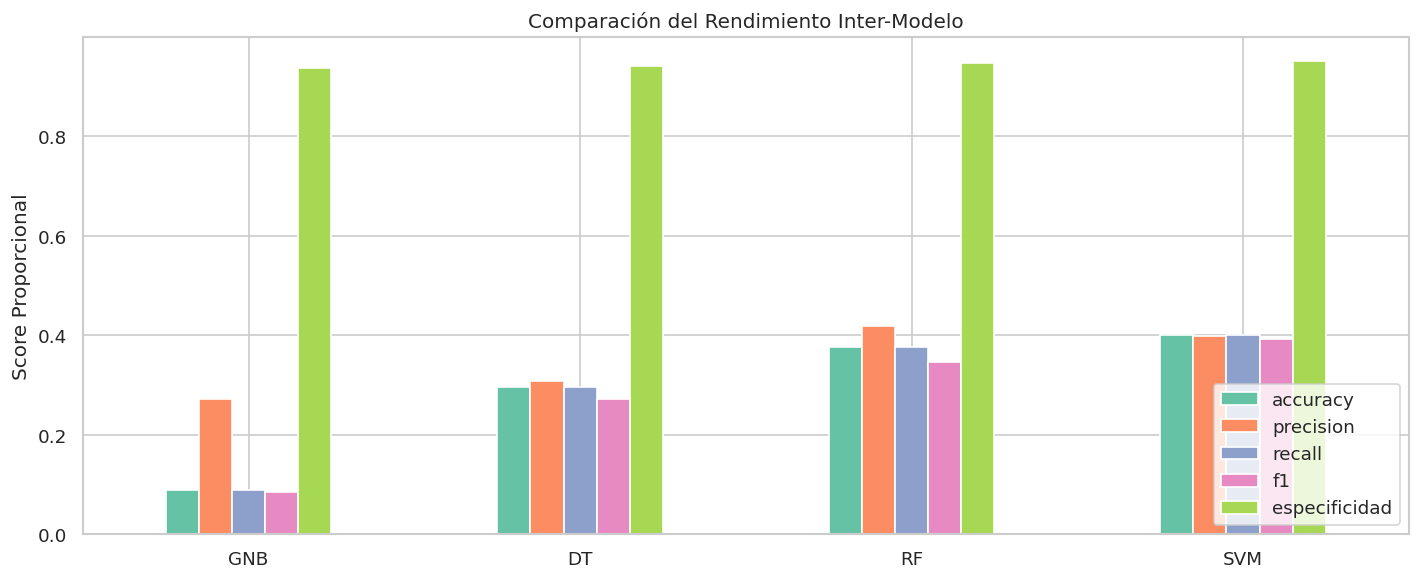

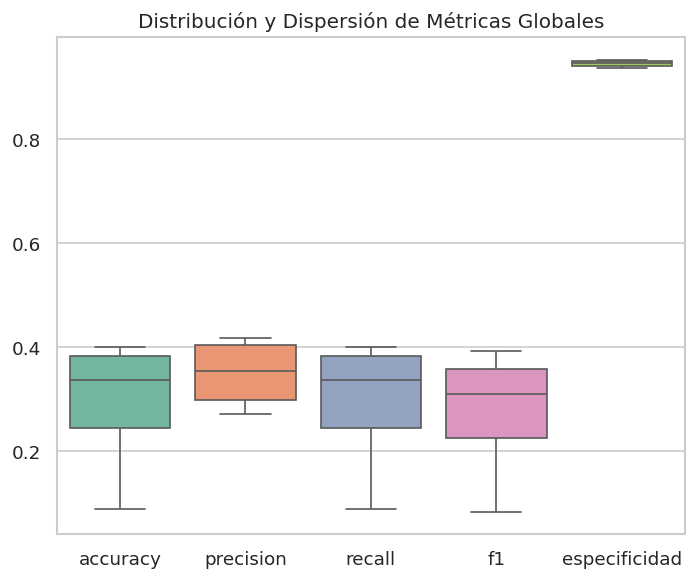

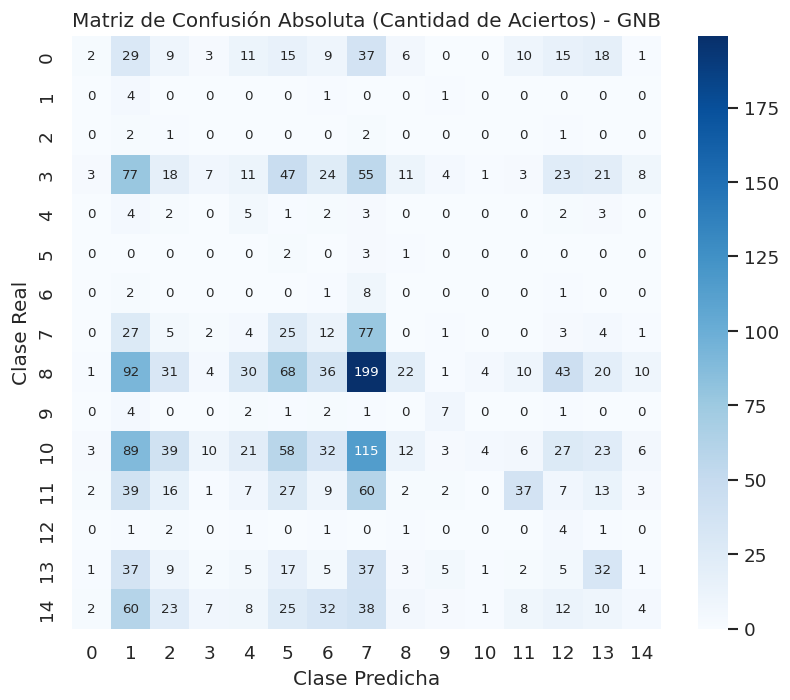

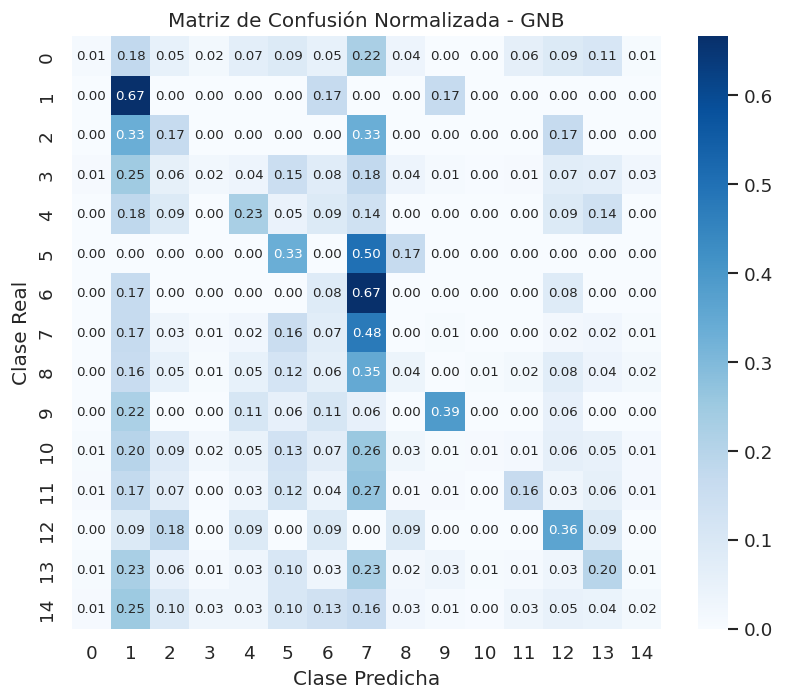

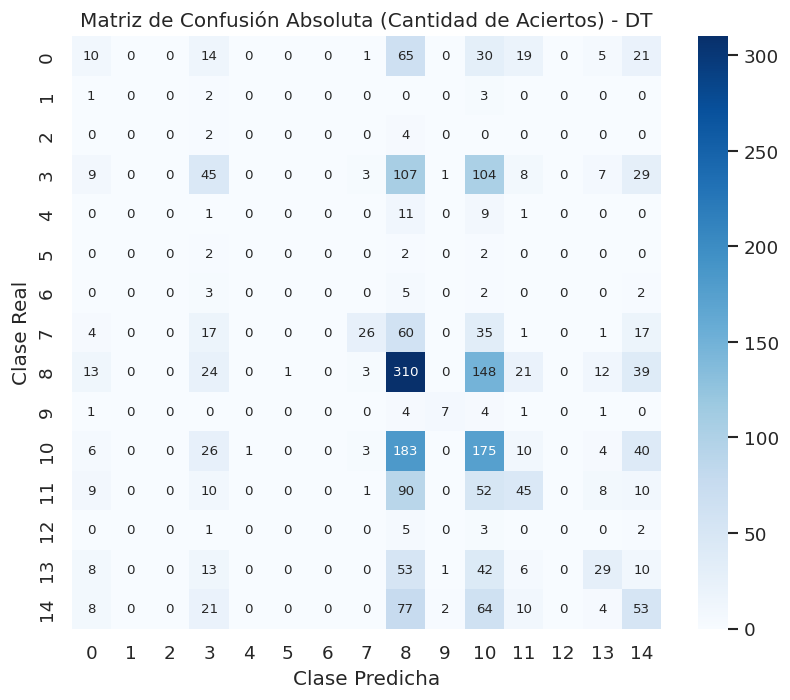

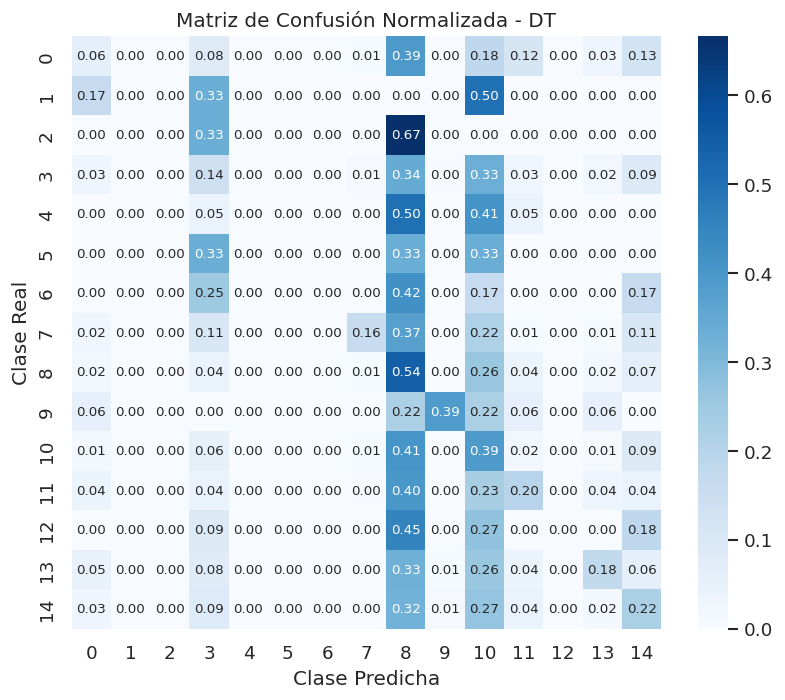

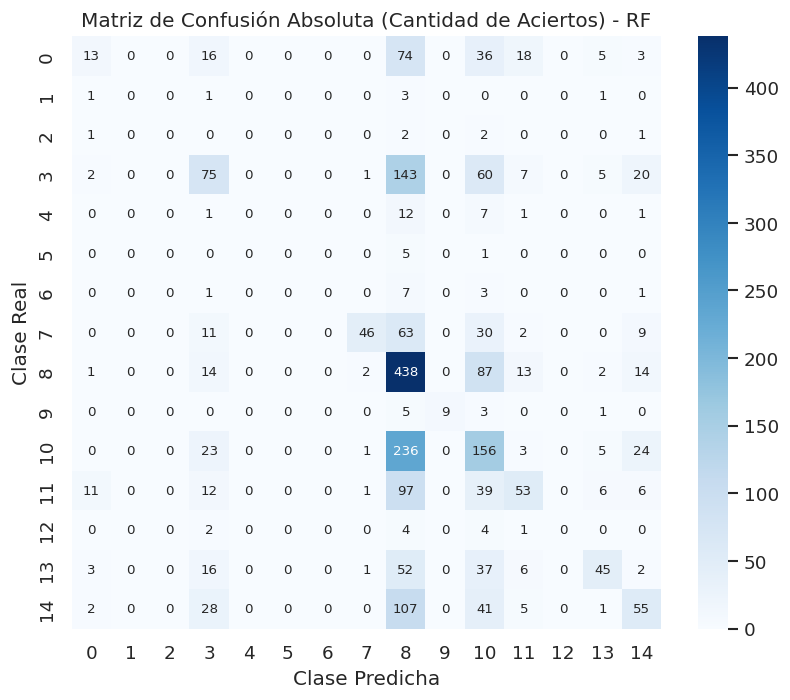

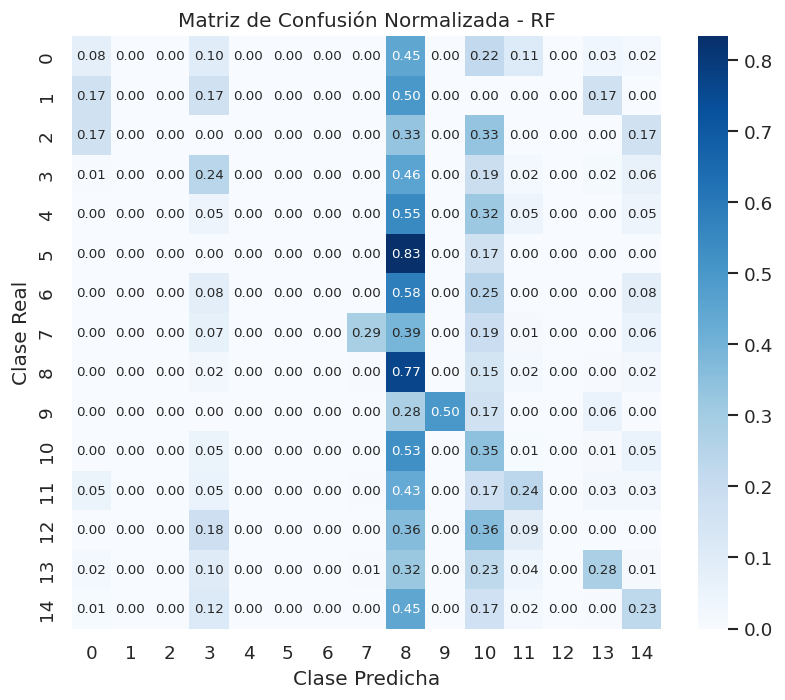

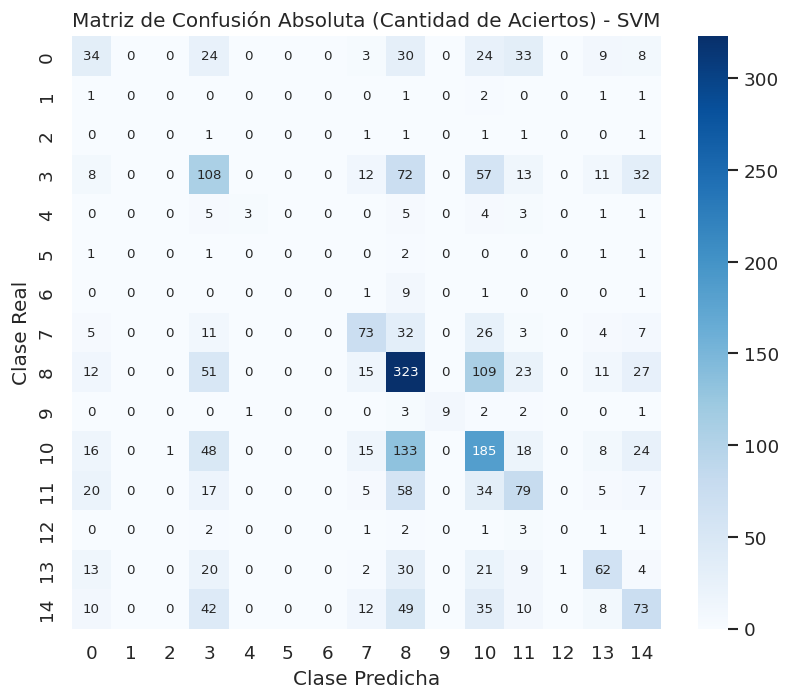

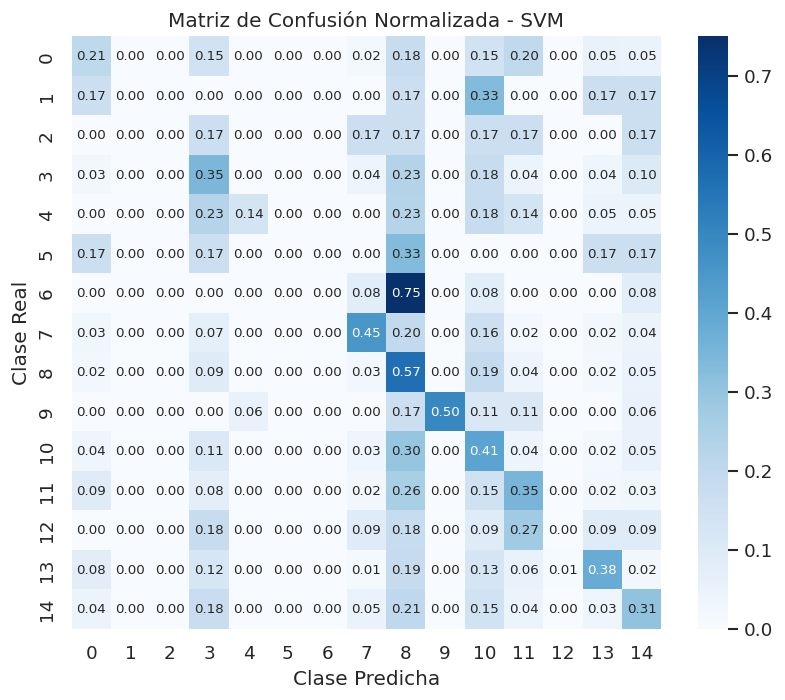

In [ ]:
df_resultados = pd.DataFrame(resultados).T
columnas_metricas = ['accuracy', 'precision', 'recall', 'f1', 'especificidad']
for col in columnas_metricas:
    df_resultados[col] = pd.to_numeric(df_resultados[col], errors='coerce')
df_resultados = df_resultados.dropna()

plt.figure(figsize=(8,5), dpi=120)
df_resultados[columnas_metricas].plot(kind='bar')
plt.title("Comparación del Rendimiento Inter-Modelo")
plt.ylabel("Score Proporcional")
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig("comparacion_modelos.png", dpi=300)
plt.show()

plt.figure(figsize=(6,5), dpi=120)
sns.boxplot(data=df_resultados[columnas_metricas])
plt.title("Distribución y Dispersión de Métricas Globales")
plt.tight_layout()
plt.savefig("boxplot_metricas.png", dpi=300)
plt.show()

for nombre in resultados:
    cm = resultados[nombre]['conf_matrix']

    plt.figure(figsize=(7, 6), dpi=120)
    sns.heatmap(cm, cmap='Blues', cbar=True, annot=True, fmt='d', annot_kws={"size": 8})
    plt.title(f"Matriz de Confusión Absoluta (Cantidad de Aciertos) - {nombre}")
    plt.xlabel("Clase Predicha")
    plt.ylabel("Clase Real")
    plt.tight_layout()
    plt.savefig(f"matriz_{nombre}.png", dpi=300, bbox_inches='tight')
    plt.show()

    cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(7, 6), dpi=120)
    sns.heatmap(cm_norm, cmap='Blues', cbar=True, annot=True, fmt='.2f', annot_kws={"size": 8})
    plt.title(f"Matriz de Confusión Normalizada - {nombre}")
    plt.xlabel("Clase Predicha")
    plt.ylabel("Clase Real")
    plt.tight_layout()
    plt.savefig(f"matriz_norm_{nombre}.png", dpi=300, bbox_inches='tight')
    plt.show()